#ALUNO : Henrique Chiabai da Silva

Análise Exploratória do conjunto de dados: DadoseDecisoes, dispoível em https://github.com/cibelerusso/Datasets/blob/main/DadoseDecisoes.csv


# Importação das bibliotecas e inicialização do DataFrame

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv(
    "https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/DadoseDecisoes.csv")

#Primeira visualização dos atributos

In [64]:
df.head()

,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não


#Exercício A: Criação de uma nova coluna classificando a produtividade dos funcionários

In [65]:
mediana_prod = df["Produtividade"].median()
df['Produtividade_bin'] = np.where(df['Produtividade'] > mediana_prod, "Alta", "Baixa")
df

,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office,Produtividade_bin
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não,Baixa
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim,Alta
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim,Alta
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim,Alta
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não,Baixa
...,...,...,...,...,...,...,...,...,...,...,...,...
225,226,36,Feminino,RH,3711.26,34,81.89,76.52,9,1,Não,Baixa
226,227,21,Feminino,Marketing,2536.32,34,85.63,100.00,0,0,Não,Baixa
227,228,43,Feminino,Vendas,5717.90,38,86.55,82.46,12,11,Não,Baixa
228,229,48,Feminino,Marketing,15638.38,38,85.72,68.05,14,5,Não,Baixa


In [66]:
df['Produtividade_bin'].value_counts()
#Impressão incial revela que os grupos de produtiivdade alta e baixa são parecidos em números

,count
Produtividade_bin,
Baixa,116
Alta,114


#Exercício B: Classificação dos atributos por tipo

In [67]:
#Variáveis numéricas inteiras
quantitativas_discretas = df[['Horas_Trabalhadas', 'Tempo_Empresa', 'Cursos_Realizados', 'Idade']]

#Variáveis numéricas mais abrangentes
quantitativas_contínuas = df [['Salário', 'Produtividade', 'Satisfação']]

#Variáveis ou categorias sem nenhuma ordem, hierarquia ou valor numérico intrínseco
qualitativas_nominais = df[['Gênero','Departamento', 'Home_Office']]

#Variáveis que possuem uma hierarquia, ordem ou ranking entre si
qualitativa_ordinal = df[['Produtividade_bin']]

#Exercício C: Análise exploratória das variáveis qualitativas

,Frequência
Gênero,
Feminino,102
Masculino,128


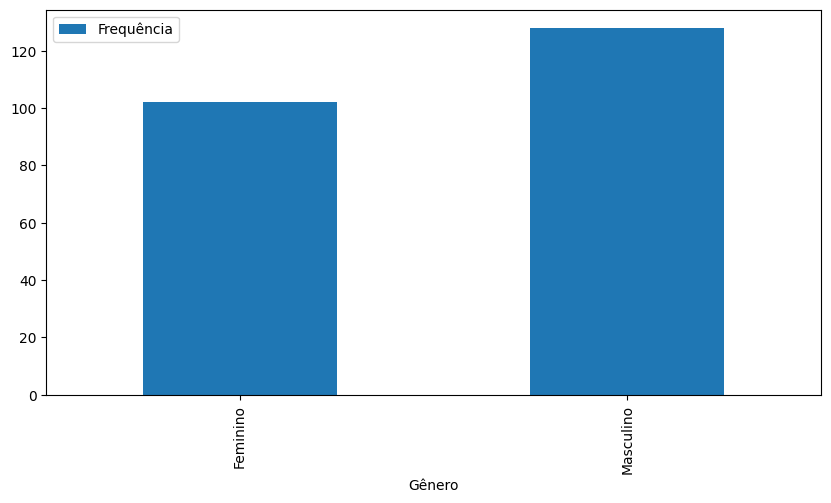

In [68]:
#Contagem da quantidade de funcionários por sexo
tab = pd.crosstab(index=df['Gênero'], columns='Frequência', colnames =[None])
tab.plot.bar()
tab

PRIMEIRA ANÁLISE QUANTO AO GÊNERO DOS FUNCIONÁRIOS:

O conjunto de dados apresenta um número levemente superior de observações de funcionários do gênero masculino.

,Frequência
Departamento,
Marketing,49
RH,45
TI,74
Vendas,62


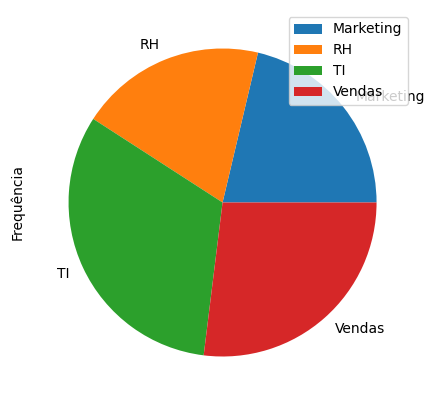

In [69]:
#Contagem de funcionários por setor
tab2 = pd.crosstab(index=df['Departamento'], columns='Frequência', colnames =[None])
tab2.plot.pie(y='Frequência', figsize=(5, 5))
tab2

SEGUNDA ANÁLISE QUANTO AO DEPARTAMENTO DOS FUNCIONÁRIOS:

A tabela e o gráfico mostram que os setores de TI e de Vendas concentram mais funcionários.

,Frequência
Produtividade_bin,
Alta,114
Baixa,116


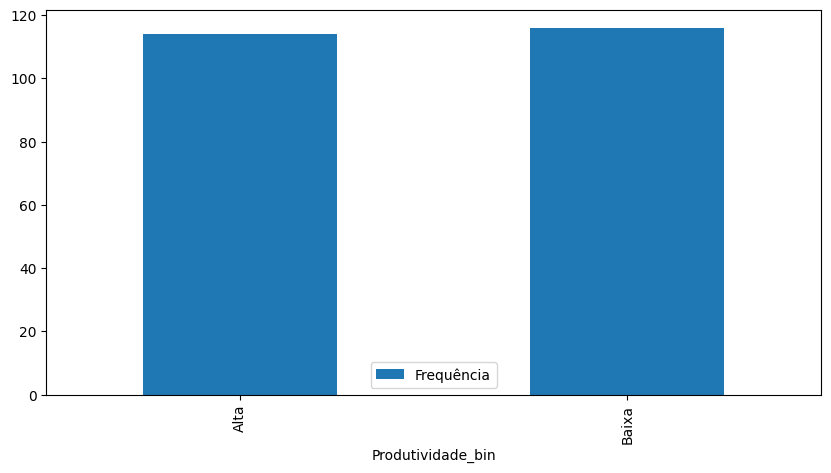

In [70]:
#Contagem de funcionários por sua produtividade
tab3 = pd.crosstab(index=df['Produtividade_bin'], columns='Frequência', colnames =[None])
tab3.plot.bar()
tab3

TERCEIRA ANÁLISE QUANTO À PRODUTIVIDADE DOS FUNCIONÁRIOS:

A tabela e o gráfico confirmam a impressão inicial de que os números de cada grupo são semelhantes, com uma pequena vantagem para a baixa produtividade.

,Frequência
Home_Office,
Não,115
Sim,115


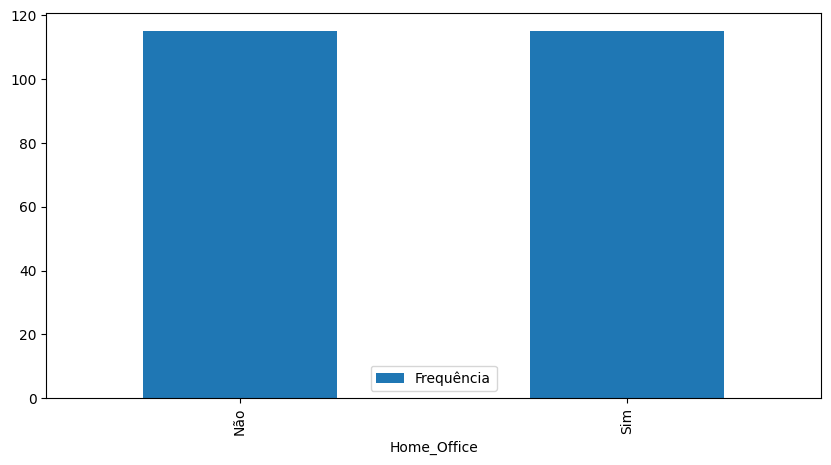

In [71]:
#Contagem de funcionários remotos e presenciais
tab4 = pd.crosstab(index=df['Home_Office'], columns='Frequência', colnames =[None])
tab4.plot.bar()
tab4

QUARTA ANÁLISE QUANTO À MODALIDADE DOS FUNCIONÁRIOS:

A tabela e o gráfico revelam que o número de funcionários que trabalham remotamente é igual ao de trabalhadores presenciais

,Feminino,Masculino
Departamento,,
Marketing,20,29
RH,26,19
TI,31,43
Vendas,25,37


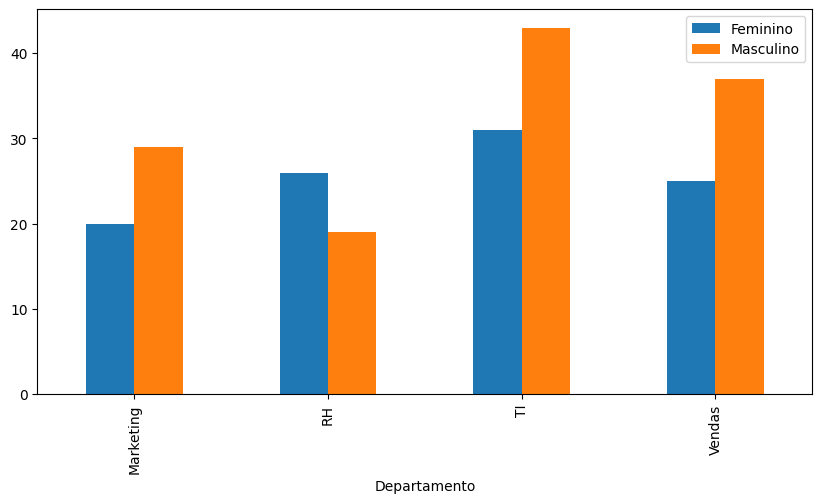

In [72]:
#Visualização da distribuição por gênero em cada departamento
tab5 = pd.crosstab(index=df['Departamento'], columns=df['Gênero'], colnames =[None])
tab5.plot.bar()
tab5

RELAÇÃO ENTRE GÊNERO E DEPARTAMENTO:

A tabela e o gráfico mostram que a maioria dos setores são majoritariamente masculinos com exeção dos Recursos Humanos que emprega mais mulheres do que homens.

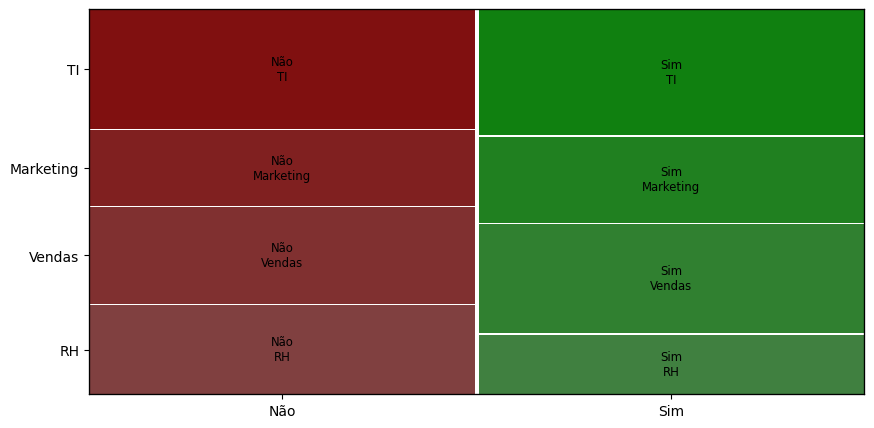

In [73]:
#Visualização da distribuição de trabalhadores remotos e presenciais por setor
from statsmodels.graphics.mosaicplot import mosaic
plt.rcParams["figure.figsize"] = [10, 5]
mosaic(df,['Home_Office', 'Departamento'] );

RELAÇÃO ENTRE HOME OFFICE E DEPARTAMENTO:

O gráfico de mosaico revela que a modalidade do trabalho nos departamentos é ligeiramente remota para tdos os setores menos no RH.

#Exercício D: Análise exploratória das variáveis quantitativas

1)ANÁLISE DAS VARIÁVEIS QUANTITATIVAS DISCRETAS

In [74]:
#Informações gerais dos atributos
quantitativas_discretas.describe()

,Horas_Trabalhadas,Tempo_Empresa,Cursos_Realizados,Idade
count,230.000000,230.000000,230.000000,230.000000
mean,38.852174,6.773913,5.204348,30.547826
std,5.816320,5.959193,4.219623,8.216762
min,30.000000,0.000000,0.000000,18.000000
25%,34.000000,1.000000,2.000000,24.000000
50%,38.000000,6.000000,5.000000,29.000000
75%,44.000000,11.000000,8.000000,35.000000
max,48.000000,30.000000,20.000000,54.000000


PRIMEIRA ANÁLISE GERAL:

Visão inicial de características básicas do conjunto de dados.

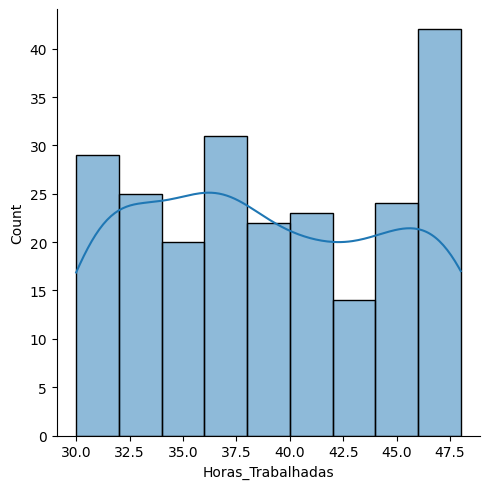

In [75]:
#Visualização das horas de trabalho em histograma
sns.displot(x=df['Horas_Trabalhadas'], kde = True)

INTERPRETAÇÃO DO GRÁFICO:

O histograma revela três pontos de maior acumulação nas 30, 38 e 48 horas de trabalho, além disso é interessante notar que a partir das 40 horas de trabalho a frequência tende a se concentrar na jornade de 48 horas por semana.

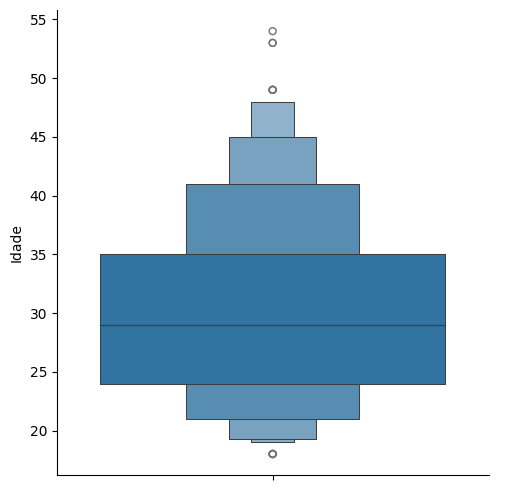

In [76]:
#Visualização das Idades em gráfico de violino
sns.catplot(y='Idade', kind='boxen', data=df)

INTERPRETAÇÃO DO GRÁFICO:

A visualização do gráfico demonstra um quantitativo maior de trabalhadores na faixa etária de 25 a 35 anos, no entanto é possível notar a presença de alguns outliers indicando a existência de alguns funcionários que se desviam do padrão de idade.

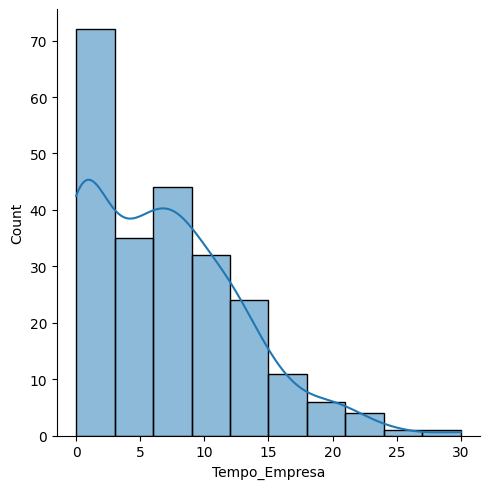

In [77]:
#Visualização do tempo na empresa como histograma
sns.displot(x=df['Tempo_Empresa'], kde =True)

INTERPRETAÇÃO DO GRÁFICO:

O histograma apresenta uma notável assimetria à esquerda em seus valores, revelendo que grande parte dos funcionários tem pouco tempo na empresa.

<Axes: ylabel='Cursos_Realizados'>

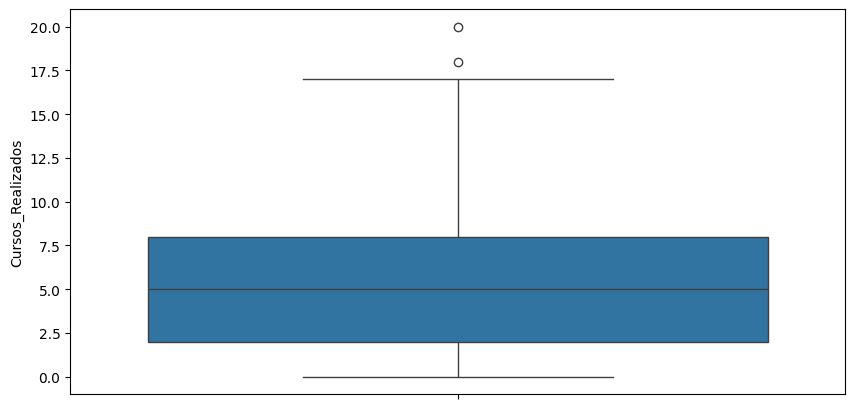

In [78]:
#Visualização do número de cursos realizados pelos funcionários em um gráfico de dispersão
sns.boxplot(y=df['Cursos_Realizados'])

INTERPRETAÇÃO DO GRÁFICO:

O "candlestick" mostra que 75% das amostras se concentram perto de 8 cursos realizados, indicando uma possível assimetria.

2)ANÁLISE DAS VARIÁVEIS QUANTITATIVAS CONTÍNUAS




In [79]:
#Informações gerais dos atributos
quantitativas_contínuas.describe()

,Salário,Produtividade,Satisfação
count,230.000000,230.000000,230.000000
mean,8029.973957,87.849870,86.149957
std,6556.329700,12.238118,12.058364
min,2536.320000,65.740000,39.420000
25%,2536.320000,77.122500,77.570000
50%,5667.560000,87.040000,87.730000
75%,12129.212500,98.425000,96.190000
max,29052.820000,112.060000,100.000000


PRIMEIRA ANÁLISE GERAL:

Visão inicial de características básicas do conjunto de dados.

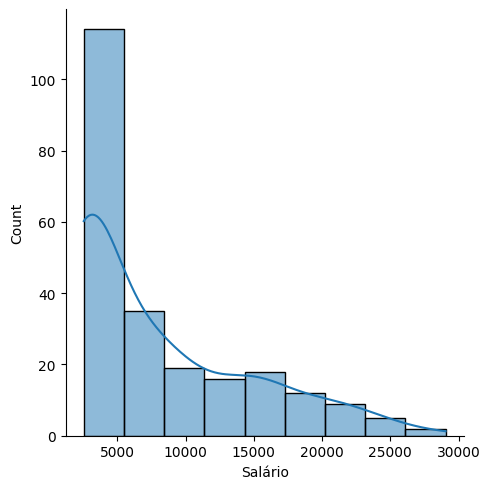

In [80]:
#Visualização do Salário em histograma
sns.displot(x=df['Salário'], kde = True)

INTERPRETAÇÃO DO GRÁFICO:

O histograma apresenta uma concentração absoluta de salários perto de 5 mil reais e menos, formando um gráfico assimétrico.

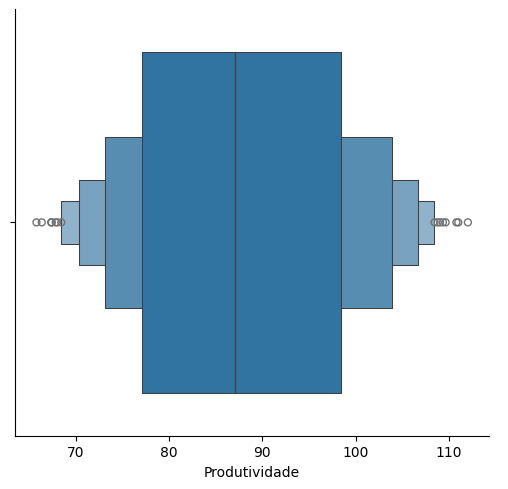

In [81]:
#Visualização da Produtividade em gráfico de violino
sns.catplot(x=df['Produtividade'], kind='boxen', data=df)

INTERPRETAÇÃO DO GRÁFICO:

O gráfico mostra um configuração simétrica, em que grande parte das amostras se encontram entre 80 e 100, no entanto é válido resssaltar a existência de outliers em grande quantidade.

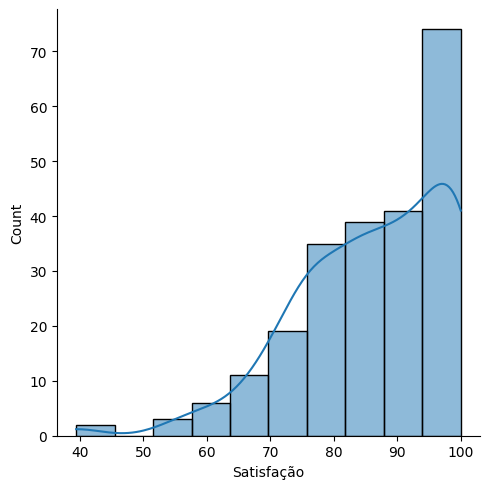

In [82]:
#Visualização da Satisfação em gráfico de violino
sns.displot(x=df['Satisfação'], kde = True)

INTERPRETAÇÃO DO GRÁFICO:

O histograma demonstra uma assimetria à direita e revela que os funcionários têm um grau alto de satisfação nessa empresa.

3)ESTUDO DA ASSOCIAÇÃO DE ATRIBUTOS  QUANTITATIVOS

In [ ]:
#Conjunto de gráficos associando todas variáveis númericas
quantitativas = quantitativas_discretas.join(quantitativas_contínuas)
sns.pairplot(quantitativas, corner=True)

PRINCIPAIS OBSERVAÇÕES REVELADAS PELOS DIAGRAMAS:


1.   O gráfico de dispersão entre satisfação e tempo de empresa mostra que quanto maior o número de anos na empresa menor é a satisfação do funcionário.
2.   O esquema que relaciona produtividade e horas de trabalho introduz a possibilidade de que maiores jornada contribuem para maiores produtividades.
3.   O conjunto de diagramas que envolvem os salários indicam que idade, tempo na empresa e número de cursos realizados contribuem para valores salariais maiores.


#Exercício E, F e G: Estudo da Associação da produtividade_bin com outras variáveis

In [ ]:
#Associação da produtividade_bin com a idade
sns.boxplot(x=df['Produtividade_bin'], y=df['Idade'])
df.groupby('Produtividade_bin')['Idade'].mean()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E A IDADE: ASSOCIAÇÃO FRACA

A tabela e o diagrama apontam para uma relação irrelevante devido a pouca variação entre os valores médios de idade e da similaridade dos boxplots. Assim, conclui-se sem evidência probabilística, que esses duas variáveis não possuem  correlação nem causalidade.

In [ ]:
#Associação da produtividade_bin com o gênero
from statsmodels.graphics.mosaicplot import mosaic
plt.rcParams["figure.figsize"] = [10, 5]
mosaic(df,['Gênero', 'Produtividade_bin'] );

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E GÊNERO: ASSOCIAÇÃO FRACA

O gráfico de mosaico mostra que o gênero dos funcionários não influencia na produtividade, vale ressaltar que essa observação não possui validação estatística.

In [ ]:
#Associação da produtividade_bin com a jornada de trabalho semanal
sns.boxplot(x=df['Produtividade_bin'], y=df['Horas_Trabalhadas'])
df.groupby('Produtividade_bin')['Horas_Trabalhadas'].mean()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E A CARGA DE TRABALHO: ASSOCIAÇÃO FORTE

Essa representação gráfica indica uma possível relação entre os dois atributos, haja vista que de acordo com os "candlestikcs" e a tabela, uma elevada produtividade está relacionada a uma jornada de trabalho média mais extensa. Assim, conclui-se sem evidência probabilística, que esses dois atributos estão diretamente ligados.

In [ ]:
#Associação da produtividade_bin com a satisfação
sns.catplot(x=df['Produtividade_bin'], y=df['Satisfação'], kind='boxen', data=df)
df.groupby('Produtividade_bin')['Satisfação'].mean()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E SATISFAÇÃO: ASSOCIAÇÃO FRACA

Esse gráfico de violino aponta, e a tabela confirma, que a interação entre os dois atributos é fraca, visto que as diferenças entres os dois formatos é mínima, novamente é interessante notar a quantidade de outliers. Assim, é possível deduzir, sem confirmação estatística, que o grau de satisfação não interfere na produtividade.

In [ ]:
#Associação da produtividade_bin com a tempo na empresa
sns.boxplot(y=df['Produtividade_bin'], x=df['Tempo_Empresa'])
df.groupby('Produtividade_bin')['Tempo_Empresa'].mean()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E TEMPO DE EMPRESA: ASSOCIAÇÃO FRACA

Esse boxplot aponta, e a tabela confirma, que a relação dos atributos é fraca. Assim, é possível deduzir, sem confirmação estatística, que maiores produtividades não necessariamente permanecem mais tempo na empresa.

In [ ]:
#Associação da produtividade_bin com o número de cursos realizados
sns.boxplot(y=df['Produtividade_bin'], x=df['Cursos_Realizados'])
df.groupby('Produtividade_bin')['Cursos_Realizados'].mean()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E NÚMERO DE CURSOS  REALIZADOS: ASSOCIAÇÃO MÉDIA

Esse boxplot aponta, e a tabela confirma, que possivelmente existe alguma relação entre as duas variáveis. Assim, é possível deduzir, sem confirmação, que funcionários com mais cursos tendem a a presentar uma produtividade maior.

In [ ]:
#Associação da produtividade_bin com os departamentos
tab6 = pd.crosstab(index=df['Departamento'], columns=df['Produtividade_bin'], colnames =[None])
tab6.plot.bar()
df.groupby('Produtividade_bin')['Departamento'].value_counts()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E DEPARTAMENTO: ASSOCIAÇÃO MÉDIA

Essa figura aponta, e a tabela confirma, que a relação entre o setor da empresa e sua produtividade é parcial, visto que a diferença entre produtividade alta e baixa em números é pequena nos departamentos, no entanto um ponto de atenção é produtividade pequena superar a elevada no RH. Assim, é possível deduzir, sem confirmação probabilística, que a área de atuação do profissional tem alguma influência em sua produtividade.

In [ ]:
#Associação da produtividade_bin com a modalidade do trabalho
tab7 = pd.crosstab(index=df['Home_Office'], columns=df['Produtividade_bin'], colnames =[None])
tab7.plot.bar()
df.groupby('Produtividade_bin')['Home_Office'].value_counts()

ANÁLISE DA ASSOCIAÇÃO ENTRE PRODUTIVIDADE_BIN E DEPARTAMENTO: ASSOCIAÇÃO FORTE

Esse diagrama mostra, e a tabela confirma, a variável Home_Office está influenciando na produtividade dos funcionários, visto que todos com alta produtividade trabalham remotamente. Assim, é possível deduzir, sem confirmação, que os profissonais remotos possuem uma pprodutividade superior.

# Exercício H: Limitações do estudo explorátorio acima

LIMITAÇÕES DESSE ESTUDO:

A ausência de análises confirmatórias, como testes de hipóteses e inferências estátisticas, para verificar a validade e significância dos resultados não permite a criação de afirmações sobre as observações, para avançar ainda mais na investigação é necessário o emprego de métodos para confirmar a causalidade além da correlação entre dois atributos.